# 00 - Cypher 语言入门（Neo4j）

本 notebook 专门用来**快速入门 Cypher**（Neo4j 的图查询语言），通过一组从易到难的例子熟悉：

- 基本查询结构：`MATCH` / `WHERE` / `RETURN`
- 图模式匹配：节点、关系、方向、多跳
- 排序、分页、聚合：`ORDER BY` / `LIMIT` / `count` / `collect`
- 管道式语法：`WITH`（Cypher 的“中间结果表”）
- 可选匹配：`OPTIONAL MATCH`
- 写入语句：`CREATE` / `MERGE` / `SET` / `DELETE`
- 参数化查询：安全 + 可复用
- 子查询：`CALL { ... }`

## 前置条件

- Neo4j 已启动（本地 Docker 或 Aura 云）
- 已加载 `data/seed_graph.cypher`（包含 Room/Device/Capability/Scene 等示例数据）
- 已配置 `.env`（`NEO4J_URI/USER/PASSWORD`）

> 如果你还没加载 seed 数据：先回到 `01_explore_neo4j.ipynb` 运行“加载 seed”那一格。


## 0. 连接 Neo4j（Python 里运行 Cypher）

下面用项目里现成的 `Neo4jConnection` 封装来执行 Cypher。


In [69]:
# 连接 Neo4j（复用项目封装）
import sys
sys.path.insert(0, '..')

from dotenv import load_dotenv
load_dotenv('../.env')

from src.graph.connection import Neo4jConnection

conn = Neo4jConnection()
conn.connect()

health = conn.health_check()
print(health)


{'status': 'healthy', 'database': 'neo4j', 'name': 'Neo4j Kernel', 'version': '2025.12.1', 'edition': 'community', 'node_count': 33, 'relationship_count': 68}


/Users/xiaotingzhou/miniconda3/lib/python3.11/site-packages/neo4j/_sync/work/result.py:635: UserWarning:

Expected a result with a single record, but found multiple.



## 1. Cypher 基本形状：MATCH / WHERE / RETURN

你可以把 Cypher 先类比为“在图上的模式匹配”。最常见的结构：

```cypher
MATCH  (pattern)
WHERE  <过滤条件>
RETURN <要返回的列>
```

- `MATCH`：指定要匹配的图模式
- `WHERE`：对匹配结果过滤（可选）
- `RETURN`：输出字段（相当于 SELECT）


In [70]:
# 例 1：找所有房间（Room），返回几个属性
rows = conn.query(
    """
    MATCH (r:Room)
    RETURN r.name AS name, r.floor AS floor, r.type AS type
    ORDER BY r.floor, r.name
    """
)
rows


[{'name': 'Bathroom', 'floor': 'First Floor', 'type': 'utility'},
 {'name': 'Home Office', 'floor': 'First Floor', 'type': 'work'},
 {'name': 'Master Bedroom', 'floor': 'First Floor', 'type': 'bedroom'},
 {'name': 'Kitchen', 'floor': 'Ground Floor', 'type': 'utility'},
 {'name': 'Living Room', 'floor': 'Ground Floor', 'type': 'entertainment'}]

## 2. 节点与属性：Label、属性过滤、字符串包含

- 节点写法：`(变量:Label {属性: 值})`
- 只写 `:Label` 表示按标签过滤
- 属性过滤既可以写在模式里 `{...}`，也可以写在 `WHERE`


In [71]:
# 例 2：按属性过滤（Kitchen 的设备）
rows = conn.query(
    """
    MATCH (r:Room {name: 'Kitchen'})-[:CONTAINS]->(d:Device)
    RETURN d.device_id AS id, d.name AS name, d.device_type AS type
    ORDER BY d.name
    """
)
rows


[{'id': 'kitchen_light_01', 'name': 'Kitchen Light', 'type': 'light'},
 {'id': 'kitchen_display_01', 'name': 'Smart Display', 'type': 'display'}]

In [72]:
# 例 3：WHERE + 字符串操作（找所有 Hue 灯）
rows = conn.query(
    """
    MATCH (d:Device)
    WHERE d.brand CONTAINS 'Hue' AND d.device_type = 'light'
    RETURN d.name AS device, d.brand AS brand, d.model AS model
    ORDER BY d.name
    """
)
rows


[{'device': 'Bedroom Light',
  'brand': 'Philips Hue',
  'model': 'White and Color Ambiance'},
 {'device': 'Bedside Lamp', 'brand': 'Philips Hue', 'model': 'Go'},
 {'device': 'Ceiling Light',
  'brand': 'Philips Hue',
  'model': 'White and Color Ambiance'},
 {'device': 'Kitchen Light',
  'brand': 'Philips Hue',
  'model': 'White Ambiance'}]

## 3. 关系（Relationship）模式：方向、类型、多跳

- 关系写法：`()-[:TYPE]->()`
- 方向重要：`->` / `<-`
- 多跳：`()-[:A]->()-[:B]->()`
- 可变长度路径：`-[:TYPE*1..3]->`（1 到 3 跳）


In [73]:
# 例 4：两跳遍历：Room -> Device -> Capability
rows = conn.query(
    """
    MATCH (r:Room {name: 'Living Room'})-[:CONTAINS]->(d:Device)-[:HAS_CAPABILITY]->(c:Capability)
    RETURN d.name AS device, collect(c.name) AS capabilities
    ORDER BY d.name
    """
)
rows


[{'device': 'Ceiling Light', 'capabilities': ['color', 'dim', 'power']},
 {'device': 'Floor Lamp', 'capabilities': ['dim', 'power']},
 {'device': 'Smart Speaker',
  'capabilities': ['announce', 'play_music', 'volume', 'power']},
 {'device': 'Smart TV', 'capabilities': ['input_select', 'volume', 'power']},
 {'device': 'Thermostat', 'capabilities': ['temperature']},
 {'device': 'Window Blinds', 'capabilities': ['open_close']}]

In [74]:
# 例 5：可变长度路径：Kitchen 1~2 跳可达的房间
rows = conn.query(
    """
    MATCH (k:Room {name: 'Kitchen'})-[:ADJACENT_TO*1..2]->(other:Room)
    RETURN DISTINCT other.name AS room
    ORDER BY room
    """
)
rows


[{'room': 'Kitchen'}, {'room': 'Living Room'}]

## 4. 参数化查询（强烈推荐）

不要用字符串拼接构造 Cypher（容易注入、也不利于缓存/复用）。

在 Neo4j Browser 里参数写作：`$room_name`；在 Python 驱动里传字典。


In [75]:
# 例 6：参数化查询（指定房间名）
room_name = "Master Bedroom"
rows = conn.query(
    """
    MATCH (r:Room {name: $room_name})-[:CONTAINS]->(d:Device)
    RETURN d.name AS device, d.device_type AS type, d.brand AS brand
    ORDER BY d.name
    """,
    {"room_name": room_name},
)
rows


[{'device': 'Bedroom Light', 'type': 'light', 'brand': 'Philips Hue'},
 {'device': 'Bedroom Speaker', 'type': 'speaker', 'brand': 'Amazon'},
 {'device': 'Bedside Lamp', 'type': 'light', 'brand': 'Philips Hue'}]

## 5. 聚合与分组：count / collect / DISTINCT

- `count(x)`：计数
- `collect(x)`：把多行聚合成列表
- `DISTINCT`：去重

Cypher 的“分组”是隐式的：**RETURN/ WITH 里出现聚合函数时，未聚合的列就是分组键**。


In [76]:
# 例 7：每个房间有多少设备
rows = conn.query(
    """
    MATCH (r:Room)-[:CONTAINS]->(d:Device)
    RETURN r.name AS room, count(d) AS device_count
    ORDER BY device_count DESC, room
    """
)
rows


[{'room': 'Living Room', 'device_count': 6},
 {'room': 'Master Bedroom', 'device_count': 3},
 {'room': 'Home Office', 'device_count': 2},
 {'room': 'Kitchen', 'device_count': 2}]

## 6. WITH：管道式中间结果表

`WITH` 是 Cypher 的“管道操作符”，把查询分成多段，每段可以：
- 过滤中间结果
- 计算中间变量
- 改变列名/结构

**类比 SQL**：`WITH` 类似 CTE（Common Table Expression），但更灵活。


In [77]:
# 例 8：WITH 管道 - 先找设备数>=3的房间，再列出这些房间的设备
rows = conn.query(
    """
    MATCH (r:Room)-[:CONTAINS]->(d:Device)
    WITH r, count(d) AS device_count
    WHERE device_count >= 3
    MATCH (r)-[:CONTAINS]->(d:Device)
    RETURN r.name AS room, device_count, collect(d.name) AS devices
    ORDER BY device_count DESC
    """
)
rows


[{'room': 'Living Room',
  'device_count': 6,
  'devices': ['Thermostat',
   'Window Blinds',
   'Smart Speaker',
   'Floor Lamp',
   'Ceiling Light',
   'Smart TV']},
 {'room': 'Master Bedroom',
  'device_count': 3,
  'devices': ['Bedroom Speaker', 'Bedside Lamp', 'Bedroom Light']}]

In [78]:
# 例 9：WITH 计算中间变量 - 找出每个房间的“能力最丰富”的设备
rows = conn.query(
    """
    MATCH (r:Room)-[:CONTAINS]->(d:Device)-[:HAS_CAPABILITY]->(c:Capability)
    WITH r, d, count(c) AS capability_count
    ORDER BY capability_count DESC
    WITH r, collect({device: d.name, count: capability_count})[0] AS top_device
    RETURN r.name AS room, top_device.device AS device, top_device.count AS capabilities
    ORDER BY room
    """
)
rows


[{'room': 'Home Office', 'device': 'Office Speaker', 'capabilities': 3},
 {'room': 'Kitchen', 'device': 'Smart Display', 'capabilities': 2},
 {'room': 'Living Room', 'device': 'Smart Speaker', 'capabilities': 4},
 {'room': 'Master Bedroom', 'device': 'Bedroom Speaker', 'capabilities': 4}]

## 7. OPTIONAL MATCH：左连接（LEFT JOIN）思维

`OPTIONAL MATCH` 表示“如果匹配不到，也保留左边，右边为 NULL”。

**类比 SQL**：`LEFT JOIN`。

**常见场景**：想列出所有房间，即使某些房间没有设备。


In [79]:
# 例 10：列出所有房间，即使没有设备也显示（用 OPTIONAL MATCH）
rows = conn.query(
    """
    MATCH (r:Room)
    OPTIONAL MATCH (r)-[:CONTAINS]->(d:Device)
    RETURN r.name AS room, 
           count(d) AS device_count,
           collect(DISTINCT d.name) AS devices
    ORDER BY r.name
    """
)
rows


[{'room': 'Bathroom', 'device_count': 0, 'devices': []},
 {'room': 'Home Office',
  'device_count': 2,
  'devices': ['Office Speaker', 'Desk Lamp']},
 {'room': 'Kitchen',
  'device_count': 2,
  'devices': ['Smart Display', 'Kitchen Light']},
 {'room': 'Living Room',
  'device_count': 6,
  'devices': ['Thermostat',
   'Window Blinds',
   'Smart Speaker',
   'Floor Lamp',
   'Ceiling Light',
   'Smart TV']},
 {'room': 'Master Bedroom',
  'device_count': 3,
  'devices': ['Bedroom Speaker', 'Bedside Lamp', 'Bedroom Light']}]

In [80]:
# 例 11：OPTIONAL MATCH - 列出所有场景，即使没有关联设备也显示
rows = conn.query(
    """
    MATCH (s:Scene)
    OPTIONAL MATCH (s)-[:APPLIES_TO]->(r:Room)
    OPTIONAL MATCH (s)-[uses:USES_DEVICE]->(d:Device)
    RETURN s.name AS scene,
           s.mood AS mood,
           r.name AS room,
           collect(DISTINCT d.name) AS devices,
           count(DISTINCT d) AS device_count
    ORDER BY s.name
    """
)
rows


[{'scene': 'Bedtime',
  'mood': 'calm',
  'room': 'Master Bedroom',
  'devices': ['Bedside Lamp', 'Bedroom Light'],
  'device_count': 2},
 {'scene': 'Focus Mode',
  'mood': 'focused',
  'room': 'Home Office',
  'devices': ['Desk Lamp'],
  'device_count': 1},
 {'scene': 'Good Morning',
  'mood': 'energetic',
  'room': 'Master Bedroom',
  'devices': ['Bedroom Speaker', 'Bedroom Light'],
  'device_count': 2},
 {'scene': 'Movie Night',
  'mood': 'relaxed',
  'room': 'Living Room',
  'devices': ['Window Blinds', 'Floor Lamp', 'Ceiling Light', 'Smart TV'],
  'device_count': 4},
 {'scene': 'Party Mode',
  'mood': 'exciting',
  'room': 'Living Room',
  'devices': ['Smart Speaker', 'Ceiling Light'],
  'device_count': 2}]

## 8. 写入语句：CREATE / MERGE / SET / DELETE

### CREATE：创建新节点/关系（如果已存在会报错）

### MERGE：存在则匹配，不存在则创建（幂等操作，推荐）

### SET：更新属性

### DELETE：删除节点/关系（需要先 DETACH DELETE 删除关系）


In [81]:
# 例 12：MERGE - 创建或匹配设备（幂等操作，推荐）
# ON CREATE：只在创建时执行
# ON MATCH：只在匹配到已存在节点时执行
try:
    result = conn.query(
        """
        MERGE (d:Device {device_id: 'test_device_001'})
        ON CREATE SET 
            d.name = 'Test Light',
            d.device_type = 'light',
            d.brand = 'Test Brand',
            d.status = 'online'
        ON MATCH SET
            d.status = 'online'  // 如果已存在，更新状态
        RETURN d.device_id AS id, d.name AS name, d.status AS status
        """
    )
    print("✓ 设备创建/更新成功")
    print(result)
except Exception as e:
    print(f"❌ 错误: {e}")


✓ 设备创建/更新成功
[{'id': 'test_device_001', 'name': 'Test Light', 'status': 'online'}]


In [82]:
# 例 13：MERGE + SET - 创建关系（如果不存在）
# 把测试设备关联到 Living Room
try:
    result = conn.query(
        """
        MATCH (r:Room {name: 'Living Room'})
        MATCH (d:Device {device_id: 'test_device_001'})
        MERGE (r)-[:CONTAINS]->(d)
        RETURN r.name AS room, d.name AS device
        """
    )
    print("✓ 关系创建成功")
    print(result)
except Exception as e:
    print(f"❌ 错误: {e}")


✓ 关系创建成功
[{'room': 'Living Room', 'device': 'Test Light'}]


In [83]:
# 例 14：SET - 更新设备状态
result = conn.query(
    """
    MATCH (d:Device {device_id: 'test_device_001'})
    SET d.status = 'offline', d.note = 'Test device'
    RETURN d.device_id AS id, d.name AS name, d.status AS status, d.note AS note
    """
)
print("✓ 属性更新成功")
result


✓ 属性更新成功


[{'id': 'test_device_001',
  'name': 'Test Light',
  'status': 'offline',
  'note': 'Test device'}]

In [84]:
# 例 15：DELETE - 删除测试数据（先删除关系，再删除节点）
try:
    # 删除关系
    conn.query(
        """
        MATCH (r:Room)-[rel:CONTAINS]->(d:Device {device_id: 'test_device_001'})
        DELETE rel
        """
    )
    # 删除节点
    conn.query(
        """
        MATCH (d:Device {device_id: 'test_device_001'})
        DELETE d
        """
    )
    print("✓ 测试数据已删除")
except Exception as e:
    print(f"❌ 错误: {e}")


✓ 测试数据已删除


## 9. CALL 子查询：复杂逻辑分步处理

`CALL { ... }` 是 Neo4j 4.0+ 引入的子查询语法，可以：
- 在查询中嵌套另一个查询
- 对每个输入行执行子查询
- 返回聚合结果

**常见用途**：统计每个标签的节点数、对每个节点执行独立计算等。


In [85]:
# 例 16：CALL 子查询 - 列出所有标签及其节点数
rows = conn.query(
    """
    CALL db.labels() YIELD label
    CALL {
        WITH label
        MATCH (n) WHERE label IN labels(n)
        RETURN count(n) AS count
    }
    RETURN label, count
    ORDER BY count DESC
    """
)
rows


Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. CALL subquery without a variable scope clause is deprecated. Use CALL (label) { ... }', position=<SummaryInputPosition line=3, column=5, offset=38>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 38, 'line': 3, 'column': 5}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: '\n    CALL db.labels() YIELD label\n    CALL {\n        WITH label\n        MATCH (n) WHERE label IN labels(n)\n        RETURN count(n) AS count\n    }\n    RETURN label, count\n    ORDER BY count DESC\n    '


[{'label': 'Device', 'count': 13},
 {'label': 'Capability', 'count': 10},
 {'label': 'Room', 'count': 5},
 {'label': 'Scene', 'count': 5}]

In [86]:
# 例 17：CALL 子查询 - 对每个房间，找出它有多少种不同的设备类型
rows = conn.query(
    """
    MATCH (r:Room)
    CALL {
        WITH r
        MATCH (r)-[:CONTAINS]->(d:Device)
        RETURN collect(DISTINCT d.device_type) AS types, count(DISTINCT d.device_type) AS type_count
    }
    RETURN r.name AS room, types, type_count
    ORDER BY type_count DESC, room
    """
)
rows


Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. CALL subquery without a variable scope clause is deprecated. Use CALL (r) { ... }', position=<SummaryInputPosition line=3, column=5, offset=24>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 24, 'line': 3, 'column': 5}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: '\n    MATCH (r:Room)\n    CALL {\n        WITH r\n        MATCH (r)-[:CONTAINS]->(d:Device)\n        RETURN collect(DISTINCT d.device_type) AS types, count(DISTINCT d.device_type) AS type_count\n    }\n    RETURN r.name AS room, types, type_count\n    ORDER BY type_count DESC, room\n    '


[{'room': 'Living Room',
  'types': ['thermostat', 'blinds', 'speaker', 'light', 'television'],
  'type_count': 5},
 {'room': 'Home Office', 'types': ['speaker', 'light'], 'type_count': 2},
 {'room': 'Kitchen', 'types': ['display', 'light'], 'type_count': 2},
 {'room': 'Master Bedroom', 'types': ['speaker', 'light'], 'type_count': 2},
 {'room': 'Bathroom', 'types': [], 'type_count': 0}]

In [87]:
# 例 18：CALL 子查询 - 列出所有关系类型及其数量
rows = conn.query(
    """
    CALL db.relationshipTypes() YIELD relationshipType
    CALL {
        WITH relationshipType
        MATCH ()-[r]->() WHERE type(r) = relationshipType
        RETURN count(r) AS count
    }
    RETURN relationshipType, count
    ORDER BY count DESC
    """
)
rows


Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. CALL subquery without a variable scope clause is deprecated. Use CALL (relationshipType) { ... }', position=<SummaryInputPosition line=3, column=5, offset=60>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 60, 'line': 3, 'column': 5}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: '\n    CALL db.relationshipTypes() YIELD relationshipType\n    CALL {\n        WITH relationshipType\n        MATCH ()-[r]->() WHERE type(r) = relationshipType\n        RETURN count(r) AS count\n    }\n    RETURN relationshipType, count\n    ORDER BY count DESC\n    '


[{'relationshipType': 'HAS_CAPABILITY', 'count': 33},
 {'relationshipType': 'CONTAINS', 'count': 13},
 {'relationshipType': 'USES_DEVICE', 'count': 11},
 {'relationshipType': 'ADJACENT_TO', 'count': 6},
 {'relationshipType': 'APPLIES_TO', 'count': 5}]

## 10. 综合练习：复杂查询组合

下面是一个综合例子，结合了多种语法：


In [88]:
# 综合例：找出所有能"播放音乐"的设备，显示它们所在的房间和所有能力
rows = conn.query(
    """
    MATCH (c:Capability {name: 'play_music'})<-[:HAS_CAPABILITY]-(d:Device)<-[:CONTAINS]-(r:Room)
    WITH r, d, collect(c.name) AS music_capabilities
    OPTIONAL MATCH (d)-[:HAS_CAPABILITY]->(other:Capability)
    WHERE other.name <> 'play_music'
    WITH r, d, music_capabilities, collect(DISTINCT other.name) AS other_capabilities
    RETURN r.name AS room,
           d.name AS device,
           d.brand AS brand,
           music_capabilities,
           other_capabilities,
           size(other_capabilities) + size(music_capabilities) AS total_capabilities
    ORDER BY total_capabilities DESC, room, device
    """
)
rows


[{'room': 'Living Room',
  'device': 'Smart Speaker',
  'brand': 'Sonos',
  'music_capabilities': ['play_music'],
  'other_capabilities': ['announce', 'volume', 'power'],
  'total_capabilities': 4},
 {'room': 'Master Bedroom',
  'device': 'Bedroom Speaker',
  'brand': 'Amazon',
  'music_capabilities': ['play_music'],
  'other_capabilities': ['announce', 'volume', 'power'],
  'total_capabilities': 4},
 {'room': 'Home Office',
  'device': 'Office Speaker',
  'brand': 'Bose',
  'music_capabilities': ['play_music'],
  'other_capabilities': ['volume', 'power'],
  'total_capabilities': 3}]

## 11. 练习题

尝试自己写以下查询：

1. **找出所有相邻的房间对**（使用 `ADJACENT_TO` 关系）
2. **统计每种设备类型（device_type）的数量**
3. **找出拥有最多能力的设备**（按 `HAS_CAPABILITY` 关系数排序）
4. **列出所有场景，显示它们使用的设备数量**（使用 `OPTIONAL MATCH`）
5. **找出所有"可调光"的设备**（即拥有 `dim` 能力），显示它们所在的房间

### 参考答案（先自己尝试！）


In [89]:
# 练习 1：相邻房间对
rows = conn.query(
    """
    MATCH (r1:Room)-[:ADJACENT_TO]->(r2:Room)
    RETURN r1.name AS room1, r2.name AS room2
    ORDER BY room1, room2
    """
)
print("练习 1：相邻房间对")
rows


练习 1：相邻房间对


[{'room1': 'Bathroom', 'room2': 'Master Bedroom'},
 {'room1': 'Home Office', 'room2': 'Master Bedroom'},
 {'room1': 'Kitchen', 'room2': 'Living Room'},
 {'room1': 'Living Room', 'room2': 'Kitchen'},
 {'room1': 'Master Bedroom', 'room2': 'Bathroom'},
 {'room1': 'Master Bedroom', 'room2': 'Home Office'}]

In [90]:
# 练习 2：每种设备类型的数量
rows = conn.query(
    """
    MATCH (d:Device)
    RETURN d.device_type AS device_type, count(d) AS count
    ORDER BY count DESC, device_type
    """
)
print("练习 2：设备类型统计")
rows


练习 2：设备类型统计


[{'device_type': 'light', 'count': 6},
 {'device_type': 'speaker', 'count': 3},
 {'device_type': 'blinds', 'count': 1},
 {'device_type': 'display', 'count': 1},
 {'device_type': 'television', 'count': 1},
 {'device_type': 'thermostat', 'count': 1}]

In [91]:
# 练习 3：拥有最多能力的设备
rows = conn.query(
    """
    MATCH (d:Device)-[:HAS_CAPABILITY]->(c:Capability)
    WITH d, count(c) AS capability_count
    ORDER BY capability_count DESC
    LIMIT 5
    MATCH (d)<-[:CONTAINS]-(r:Room)
    RETURN r.name AS room, d.name AS device, capability_count
    ORDER BY capability_count DESC
    """
)
print("练习 3：能力最丰富的设备（Top 5）")
rows


练习 3：能力最丰富的设备（Top 5）


[{'room': 'Living Room', 'device': 'Smart Speaker', 'capability_count': 4},
 {'room': 'Master Bedroom',
  'device': 'Bedroom Speaker',
  'capability_count': 4},
 {'room': 'Master Bedroom', 'device': 'Bedside Lamp', 'capability_count': 3},
 {'room': 'Master Bedroom', 'device': 'Bedroom Light', 'capability_count': 3},
 {'room': 'Home Office', 'device': 'Office Speaker', 'capability_count': 3}]

In [92]:
# 练习 4：场景及其使用的设备数量
rows = conn.query(
    """
    MATCH (s:Scene)
    OPTIONAL MATCH (s)-[:USES_DEVICE]->(d:Device)
    OPTIONAL MATCH (s)-[:APPLIES_TO]->(r:Room)
    RETURN s.name AS scene,
           s.mood AS mood,
           r.name AS room,
           count(DISTINCT d) AS device_count,
           collect(DISTINCT d.name) AS devices
    ORDER BY device_count DESC, scene
    """
)
print("练习 4：场景及其设备")
rows


练习 4：场景及其设备


[{'scene': 'Movie Night',
  'mood': 'relaxed',
  'room': 'Living Room',
  'device_count': 4,
  'devices': ['Window Blinds', 'Floor Lamp', 'Ceiling Light', 'Smart TV']},
 {'scene': 'Bedtime',
  'mood': 'calm',
  'room': 'Master Bedroom',
  'device_count': 2,
  'devices': ['Bedside Lamp', 'Bedroom Light']},
 {'scene': 'Good Morning',
  'mood': 'energetic',
  'room': 'Master Bedroom',
  'device_count': 2,
  'devices': ['Bedroom Speaker', 'Bedroom Light']},
 {'scene': 'Party Mode',
  'mood': 'exciting',
  'room': 'Living Room',
  'device_count': 2,
  'devices': ['Smart Speaker', 'Ceiling Light']},
 {'scene': 'Focus Mode',
  'mood': 'focused',
  'room': 'Home Office',
  'device_count': 1,
  'devices': ['Desk Lamp']}]

In [93]:
# 练习 5：可调光的设备及其房间
rows = conn.query(
    """
    MATCH (c:Capability {name: 'dim'})<-[:HAS_CAPABILITY]-(d:Device)<-[:CONTAINS]-(r:Room)
    RETURN r.name AS room, d.name AS device, d.device_type AS type, d.brand AS brand
    ORDER BY room, device
    """
)
print("练习 5：可调光设备")
rows


练习 5：可调光设备


[{'room': 'Home Office',
  'device': 'Desk Lamp',
  'type': 'light',
  'brand': 'BenQ'},
 {'room': 'Kitchen',
  'device': 'Kitchen Light',
  'type': 'light',
  'brand': 'Philips Hue'},
 {'room': 'Living Room',
  'device': 'Ceiling Light',
  'type': 'light',
  'brand': 'Philips Hue'},
 {'room': 'Living Room',
  'device': 'Floor Lamp',
  'type': 'light',
  'brand': 'IKEA Tradfri'},
 {'room': 'Master Bedroom',
  'device': 'Bedroom Light',
  'type': 'light',
  'brand': 'Philips Hue'},
 {'room': 'Master Bedroom',
  'device': 'Bedside Lamp',
  'type': 'light',
  'brand': 'Philips Hue'}]

## 12. 图数据可视化

让我们用 Python 可视化工具来展示 Neo4j 中的图结构，更直观地理解数据关系。

### 12.1 安装可视化库（如果需要）

### 查询语句（只读）
- `MATCH (n:Label {prop: value})` - 匹配节点
- `MATCH ()-[r:TYPE]->()` - 匹配关系
- `WHERE condition` - 过滤条件
- `RETURN expr AS alias` - 返回结果
- `ORDER BY expr [ASC|DESC]` - 排序
- `LIMIT n` - 限制结果数
- `SKIP n` - 跳过前 n 条

### 聚合函数
- `count(x)` - 计数
- `collect(x)` - 聚合成列表
- `sum(x)` / `avg(x)` / `min(x)` / `max(x)` - 数值聚合
- `DISTINCT` - 去重

### 管道操作
- `WITH expr AS alias` - 中间结果表
- `UNWIND list AS item` - 展开列表为多行

### 可选匹配
- `OPTIONAL MATCH` - 左连接

### 写入语句
- `CREATE (n:Label {prop: value})` - 创建节点
- `MERGE (n:Label {prop: value})` - 存在则匹配，不存在则创建
- `SET n.prop = value` - 更新属性
- `DELETE n` - 删除节点
- `DETACH DELETE n` - 删除节点及所有关系

### 子查询
- `CALL { ... }` - 子查询块

### 参数化
- `$param_name` - 参数占位符（在 Python 中传字典）

---

**下一步**：完成本 notebook 后，继续学习 `01_explore_neo4j.ipynb` 了解如何在实际项目中使用这些查询！


In [94]:
# 检查并安装可视化库
try:
    import networkx as nx
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    from matplotlib import font_manager
    import platform
    VISUALIZATION_AVAILABLE = True
    print("✓ NetworkX 和 Matplotlib 已安装")
    
    # 设置中文字体（解决中文乱码问题）
    plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans', 'sans-serif']
    plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
    
    # 尝试设置更好的中文字体
    system = platform.system()
    if system == 'Darwin':  # macOS
        # macOS 常见中文字体
        chinese_fonts = ['Arial Unicode MS', 'PingFang SC', 'STHeiti', 'Heiti SC']
    elif system == 'Windows':
        chinese_fonts = ['Microsoft YaHei', 'SimHei', 'SimSun']
    else:  # Linux
        chinese_fonts = ['WenQuanYi Micro Hei', 'Noto Sans CJK SC', 'DejaVu Sans']
    
    # 查找可用的中文字体
    available_fonts = [f.name for f in font_manager.fontManager.ttflist]
    for font in chinese_fonts:
        if font in available_fonts:
            plt.rcParams['font.sans-serif'] = [font] + plt.rcParams['font.sans-serif']
            print(f"✓ 已设置中文字体: {font}")
            break
    else:
        print("⚠️ 未找到中文字体，可能显示为方块，建议安装中文字体")
        
except ImportError:
    print("⚠️ 需要安装可视化库:")
    print("  pip install networkx matplotlib")
    VISUALIZATION_AVAILABLE = False

try:
    import plotly.graph_objects as go
    import plotly.express as px
    PLOTLY_AVAILABLE = True
    print("✓ Plotly 已安装（可选，用于交互式图表）")
except ImportError:
    PLOTLY_AVAILABLE = False
    print("⚠️ Plotly 未安装（可选）: pip install plotly")


✓ NetworkX 和 Matplotlib 已安装
✓ 已设置中文字体: Arial Unicode MS
✓ Plotly 已安装（可选，用于交互式图表）


### 12.2 可视化 1：房间-设备关系图（NetworkX + Matplotlib）


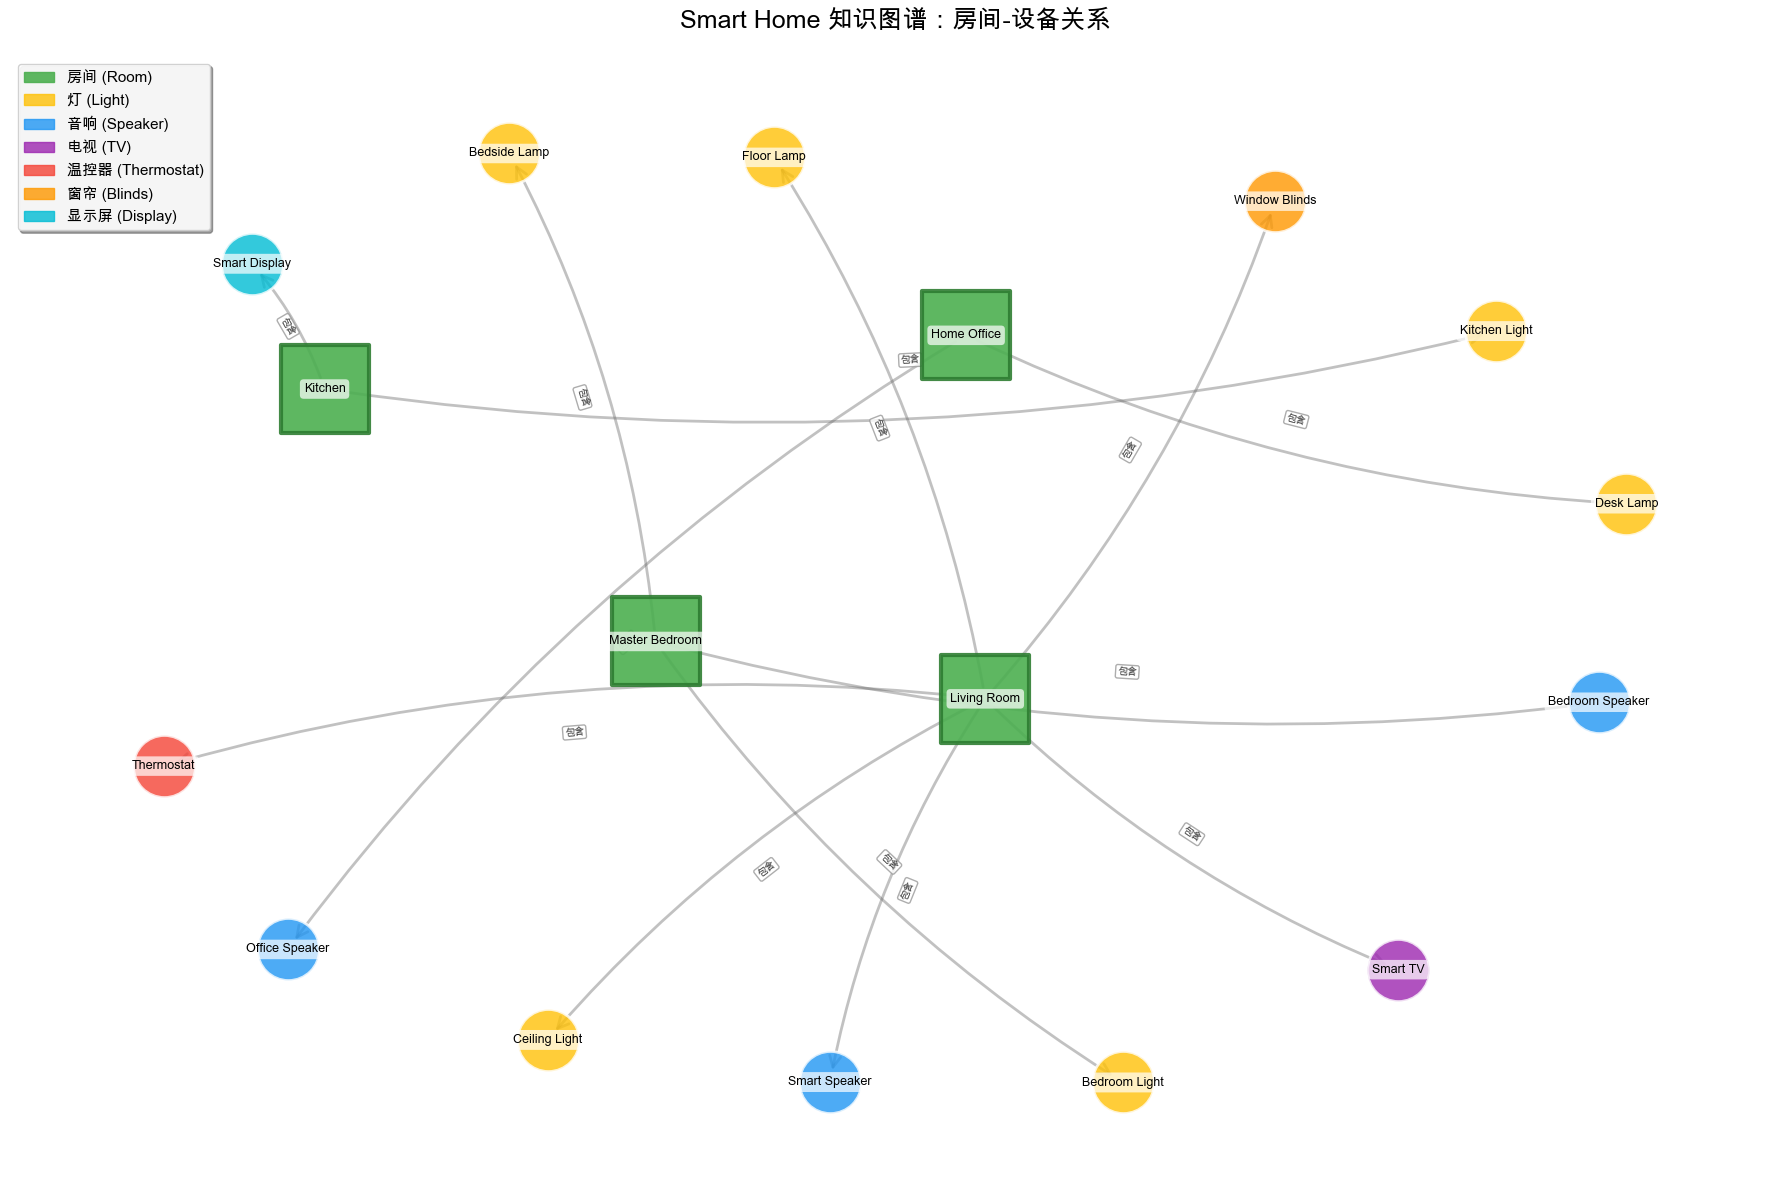


图统计:
  节点数: 17 (房间: 4, 设备: 13)
  边数: 13
  关系类型: CONTAINS (包含)


In [95]:
if VISUALIZATION_AVAILABLE:
    # 查询房间-设备关系（包含关系类型）
    room_device_data = conn.query("""
        MATCH (r:Room)-[rel:CONTAINS]->(d:Device)
        RETURN r.name AS room, r.type AS room_type, 
               d.name AS device, d.device_type AS device_type,
               type(rel) AS relationship_type
        ORDER BY room, device
    """)
    
    # 创建 NetworkX 有向图（显示关系方向）
    G = nx.DiGraph()
    
    # 添加节点和边
    rooms = set()
    devices = set()
    for row in room_device_data:
        room = row['room']
        device = row['device']
        room_type = row['room_type']
        device_type = row['device_type']
        rel_type = row['relationship_type']
        
        rooms.add(room)
        devices.add(device)
        
        # 添加节点（带属性）
        G.add_node(room, node_type='room', room_type=room_type)
        G.add_node(device, node_type='device', device_type=device_type)
        
        # 添加边（带关系类型）
        G.add_edge(room, device, relationship=rel_type)
    
    # 创建图形
    plt.figure(figsize=(18, 12))
    
    # 使用 spring layout（力导向布局）
    pos = nx.spring_layout(G, k=3, iterations=100, seed=42)
    
    # 按节点类型分组绘制
    room_nodes = [n for n in G.nodes() if G.nodes[n].get('node_type') == 'room']
    device_nodes = [n for n in G.nodes() if G.nodes[n].get('node_type') == 'device']
    
    # 绘制边（带箭头，显示关系）
    edges = G.edges()
    nx.draw_networkx_edges(G, pos, edges, alpha=0.4, edge_color='#666666', 
                          width=2, arrows=True, arrowsize=20, 
                          arrowstyle='->', connectionstyle='arc3,rad=0.1')
    
    # 绘制房间节点（大方形，带边框）
    nx.draw_networkx_nodes(G, pos, nodelist=room_nodes, 
                          node_color='#4CAF50', node_size=4000, 
                          alpha=0.9, node_shape='s', 
                          edgecolors='#2E7D32', linewidths=3)
    
    # 绘制设备节点（圆形，按类型着色，带边框）
    device_colors = {
        'light': '#FFC107',
        'speaker': '#2196F3',
        'television': '#9C27B0',
        'thermostat': '#F44336',
        'blinds': '#FF9800',
        'display': '#00BCD4'
    }
    
    for device_type, color in device_colors.items():
        type_devices = [n for n in device_nodes 
                       if G.nodes[n].get('device_type') == device_type]
        if type_devices:
            nx.draw_networkx_nodes(G, pos, nodelist=type_devices,
                                  node_color=color, node_size=2000,
                                  alpha=0.8, edgecolors='white', linewidths=2)
    
    # 添加节点标签（使用更好的字体和样式）
    node_labels = {n: n for n in G.nodes()}
    nx.draw_networkx_labels(G, pos, node_labels, 
                           font_size=9, font_weight='bold',
                           font_family='sans-serif',
                           bbox=dict(boxstyle='round,pad=0.3', 
                                   facecolor='white', 
                                   edgecolor='none', 
                                   alpha=0.7))
    
    # 添加关系标签（在边的中间位置）
    edge_labels = {}
    for (u, v) in G.edges():
        rel_type = G[u][v].get('relationship', '')
        # 简化关系标签显示
        if rel_type == 'CONTAINS':
            edge_labels[(u, v)] = '包含'
        else:
            edge_labels[(u, v)] = rel_type
    
    # 只显示部分关系标签（避免太拥挤）
    # 可以选择性地显示，或者全部显示
    nx.draw_networkx_edge_labels(G, pos, edge_labels, 
                                 font_size=7, font_color='#333333',
                                 bbox=dict(boxstyle='round,pad=0.2',
                                         facecolor='white',
                                         edgecolor='#999999',
                                         alpha=0.8))
    
    plt.title("Smart Home 知识图谱：房间-设备关系", 
             fontsize=18, fontweight='bold', pad=20)
    plt.axis('off')
    plt.tight_layout()
    
    # 添加图例（使用更好的样式）
    legend_elements = [
        mpatches.Patch(color='#4CAF50', label='房间 (Room)', alpha=0.9),
        mpatches.Patch(color='#FFC107', label='灯 (Light)', alpha=0.8),
        mpatches.Patch(color='#2196F3', label='音响 (Speaker)', alpha=0.8),
        mpatches.Patch(color='#9C27B0', label='电视 (TV)', alpha=0.8),
        mpatches.Patch(color='#F44336', label='温控器 (Thermostat)', alpha=0.8),
        mpatches.Patch(color='#FF9800', label='窗帘 (Blinds)', alpha=0.8),
        mpatches.Patch(color='#00BCD4', label='显示屏 (Display)', alpha=0.8),
    ]
    plt.legend(handles=legend_elements, loc='upper left', fontsize=11,
              framealpha=0.9, fancybox=True, shadow=True)
    
    plt.show()
    
    print(f"\n图统计:")
    print(f"  节点数: {G.number_of_nodes()} (房间: {len(room_nodes)}, 设备: {len(device_nodes)})")
    print(f"  边数: {G.number_of_edges()}")
    print(f"  关系类型: CONTAINS (包含)")
else:
    print("⚠️ 需要安装 networkx 和 matplotlib 才能可视化")


### 12.3 可视化 2：设备-能力关系图

展示每个设备拥有哪些能力（Capability）。


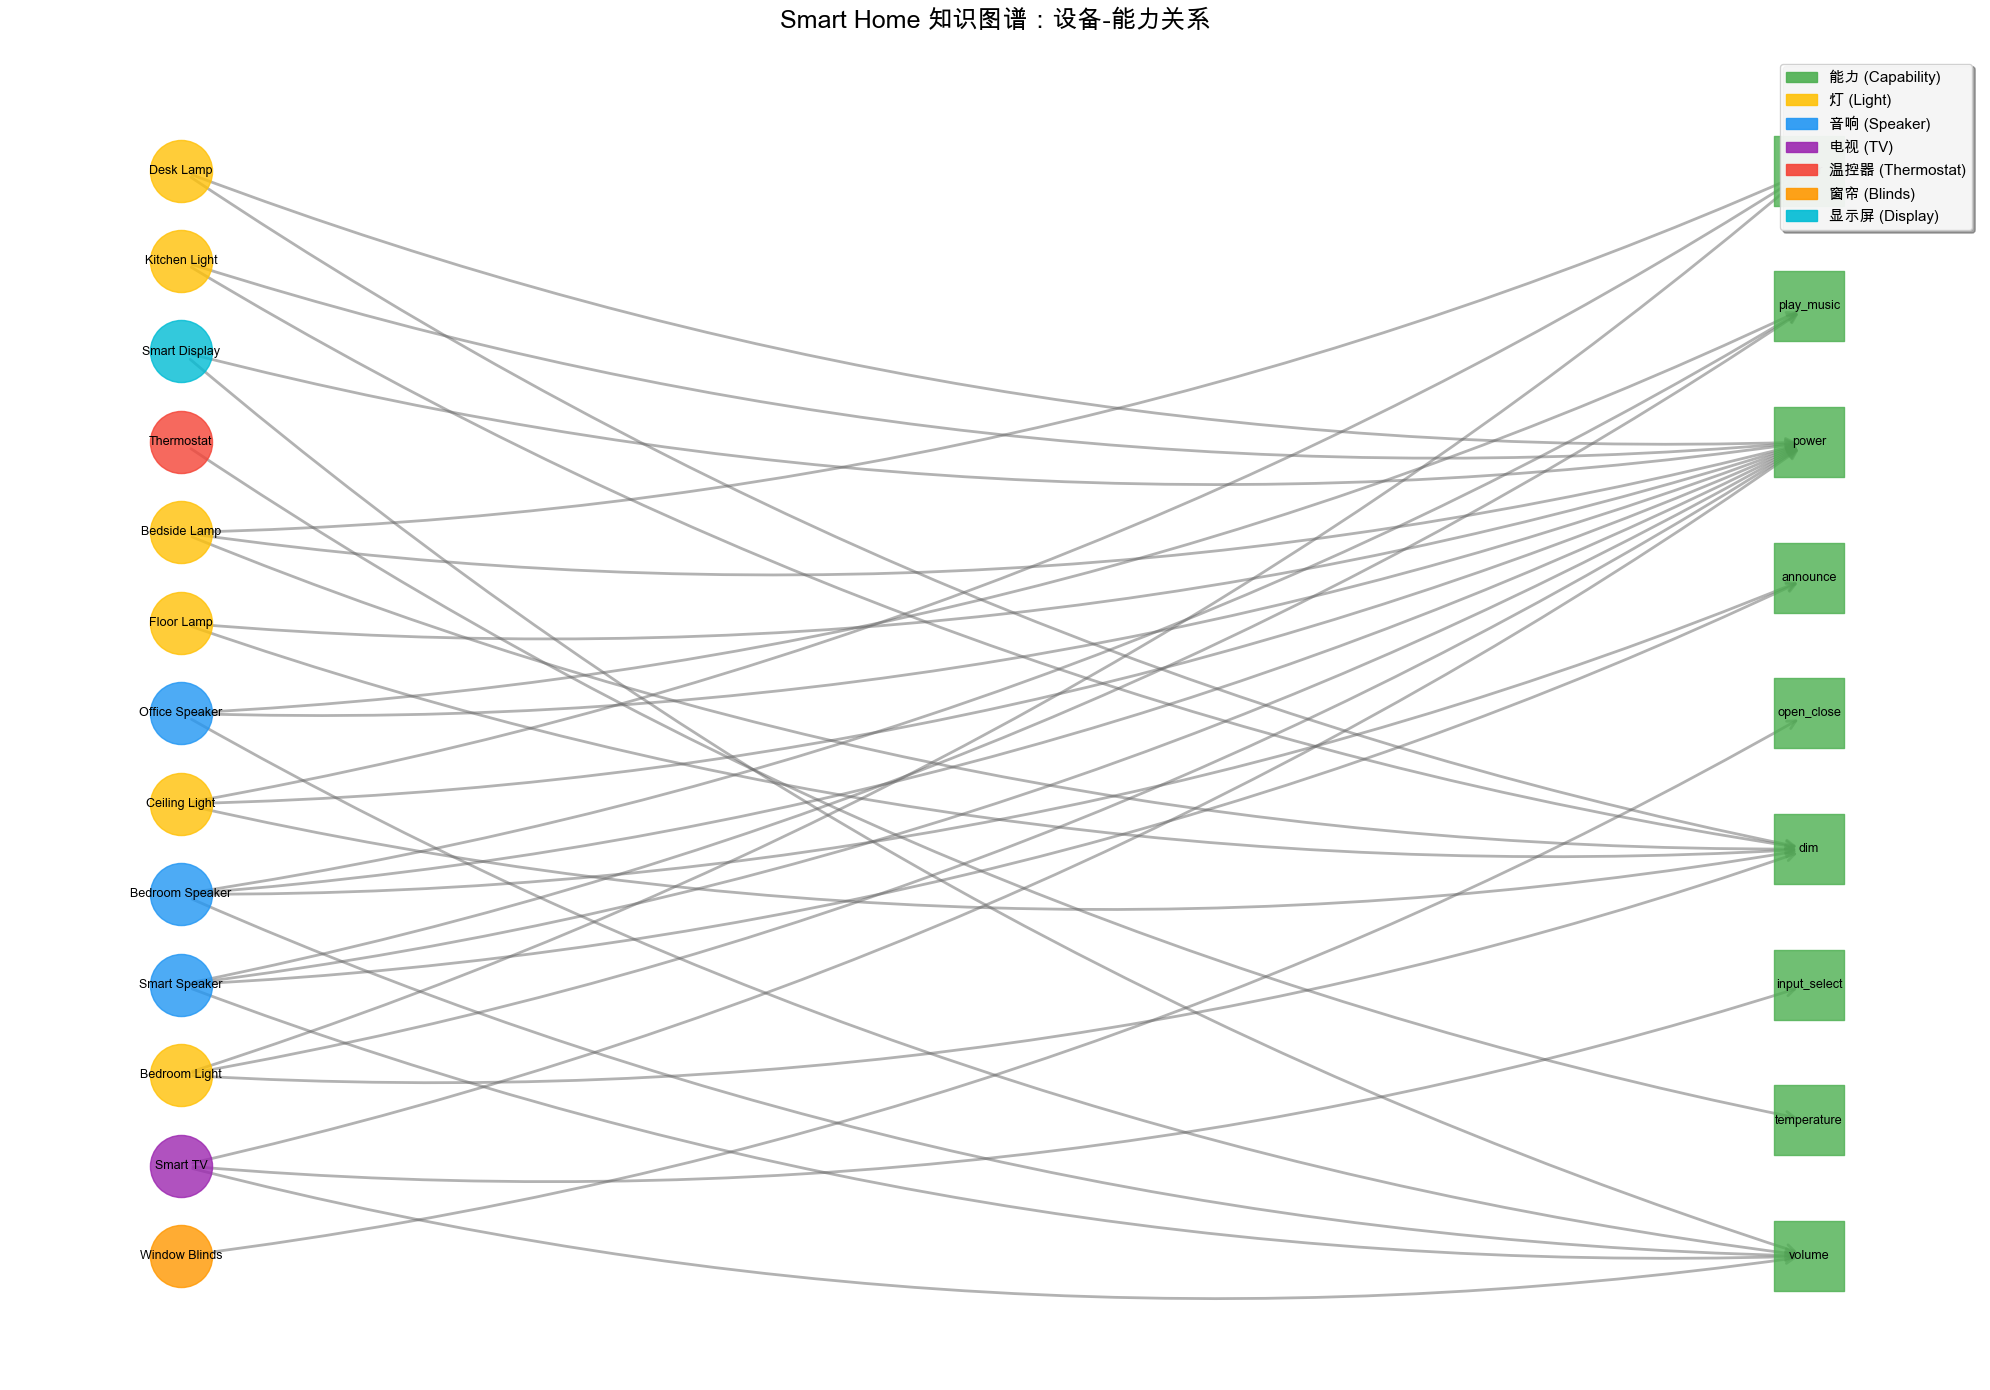


图统计:
  设备节点: 13
  能力节点: 9
  关系数: 33
  关系类型: HAS_CAPABILITY (拥有能力)


In [96]:
if VISUALIZATION_AVAILABLE:
    # 查询设备-能力关系（包含关系类型）
    device_cap_data = conn.query("""
        MATCH (d:Device)-[rel:HAS_CAPABILITY]->(c:Capability)
        RETURN d.name AS device, d.device_type AS device_type,
               c.name AS capability, type(rel) AS relationship_type
        ORDER BY device, capability
    """)
    
    # 创建有向二分图（显示关系方向）
    G2 = nx.DiGraph()
    
    device_nodes = set()
    capability_nodes = set()
    
    for row in device_cap_data:
        device = row['device']
        capability = row['capability']
        device_type = row['device_type']
        
        device_nodes.add(device)
        capability_nodes.add(capability)
        
        G2.add_node(device, node_type='device', device_type=device_type)
        G2.add_node(capability, node_type='capability')
        G2.add_edge(device, capability, relationship=rel_type)
    
    # 创建图形
    plt.figure(figsize=(20, 14))
    
    # 使用 bipartite layout（二分图布局）
    pos = nx.bipartite_layout(G2, device_nodes, align='vertical')
    
    # 绘制边（带箭头，显示关系方向）
    edges = G2.edges()
    nx.draw_networkx_edges(G2, pos, edges, alpha=0.5, edge_color='#666666', 
                          width=2, arrows=True, arrowsize=15,
                          arrowstyle='->', connectionstyle='arc3,rad=0.1')
    
    # 绘制设备节点（左侧）
    device_colors = {
        'light': '#FFC107',
        'speaker': '#2196F3',
        'television': '#9C27B0',
        'thermostat': '#F44336',
        'blinds': '#FF9800',
        'display': '#00BCD4'
    }
    
    for device_type, color in device_colors.items():
        type_devices = [n for n in device_nodes 
                       if G2.nodes[n].get('device_type') == device_type]
        if type_devices:
            nx.draw_networkx_nodes(G2, pos, nodelist=type_devices,
                                  node_color=color, node_size=2000,
                                  alpha=0.8, node_shape='o')
    
    # 绘制能力节点（右侧）
    nx.draw_networkx_nodes(G2, pos, nodelist=list(capability_nodes),
                          node_color='#4CAF50', node_size=2500,
                          alpha=0.8, node_shape='s')
    
    # 添加标签
    nx.draw_networkx_labels(G2, pos, font_size=9, font_weight='bold')
    
    plt.title("Smart Home 知识图谱：设备-能力关系", 
             fontsize=18, fontweight='bold', pad=20)
    plt.axis('off')
    plt.tight_layout()
    
    # 添加图例
    legend_elements = [
        mpatches.Patch(color='#4CAF50', label='能力 (Capability)', alpha=0.9),
        mpatches.Patch(color='#FFC107', label='灯 (Light)', alpha=0.9),
        mpatches.Patch(color='#2196F3', label='音响 (Speaker)', alpha=0.9),
        mpatches.Patch(color='#9C27B0', label='电视 (TV)', alpha=0.9),
        mpatches.Patch(color='#F44336', label='温控器 (Thermostat)', alpha=0.9),
        mpatches.Patch(color='#FF9800', label='窗帘 (Blinds)', alpha=0.9),
        mpatches.Patch(color='#00BCD4', label='显示屏 (Display)', alpha=0.9),
    ]
    plt.legend(handles=legend_elements, loc='upper right', fontsize=11,
              framealpha=0.9, fancybox=True, shadow=True)
    
    plt.show()
    
    print(f"\n图统计:")
    print(f"  设备节点: {len(device_nodes)}")
    print(f"  能力节点: {len(capability_nodes)}")
    print(f"  关系数: {G2.number_of_edges()}")
    print(f"  关系类型: HAS_CAPABILITY (拥有能力)")


### 12.4 可视化 3：房间邻接关系图

展示哪些房间是相邻的（ADJACENT_TO 关系）。


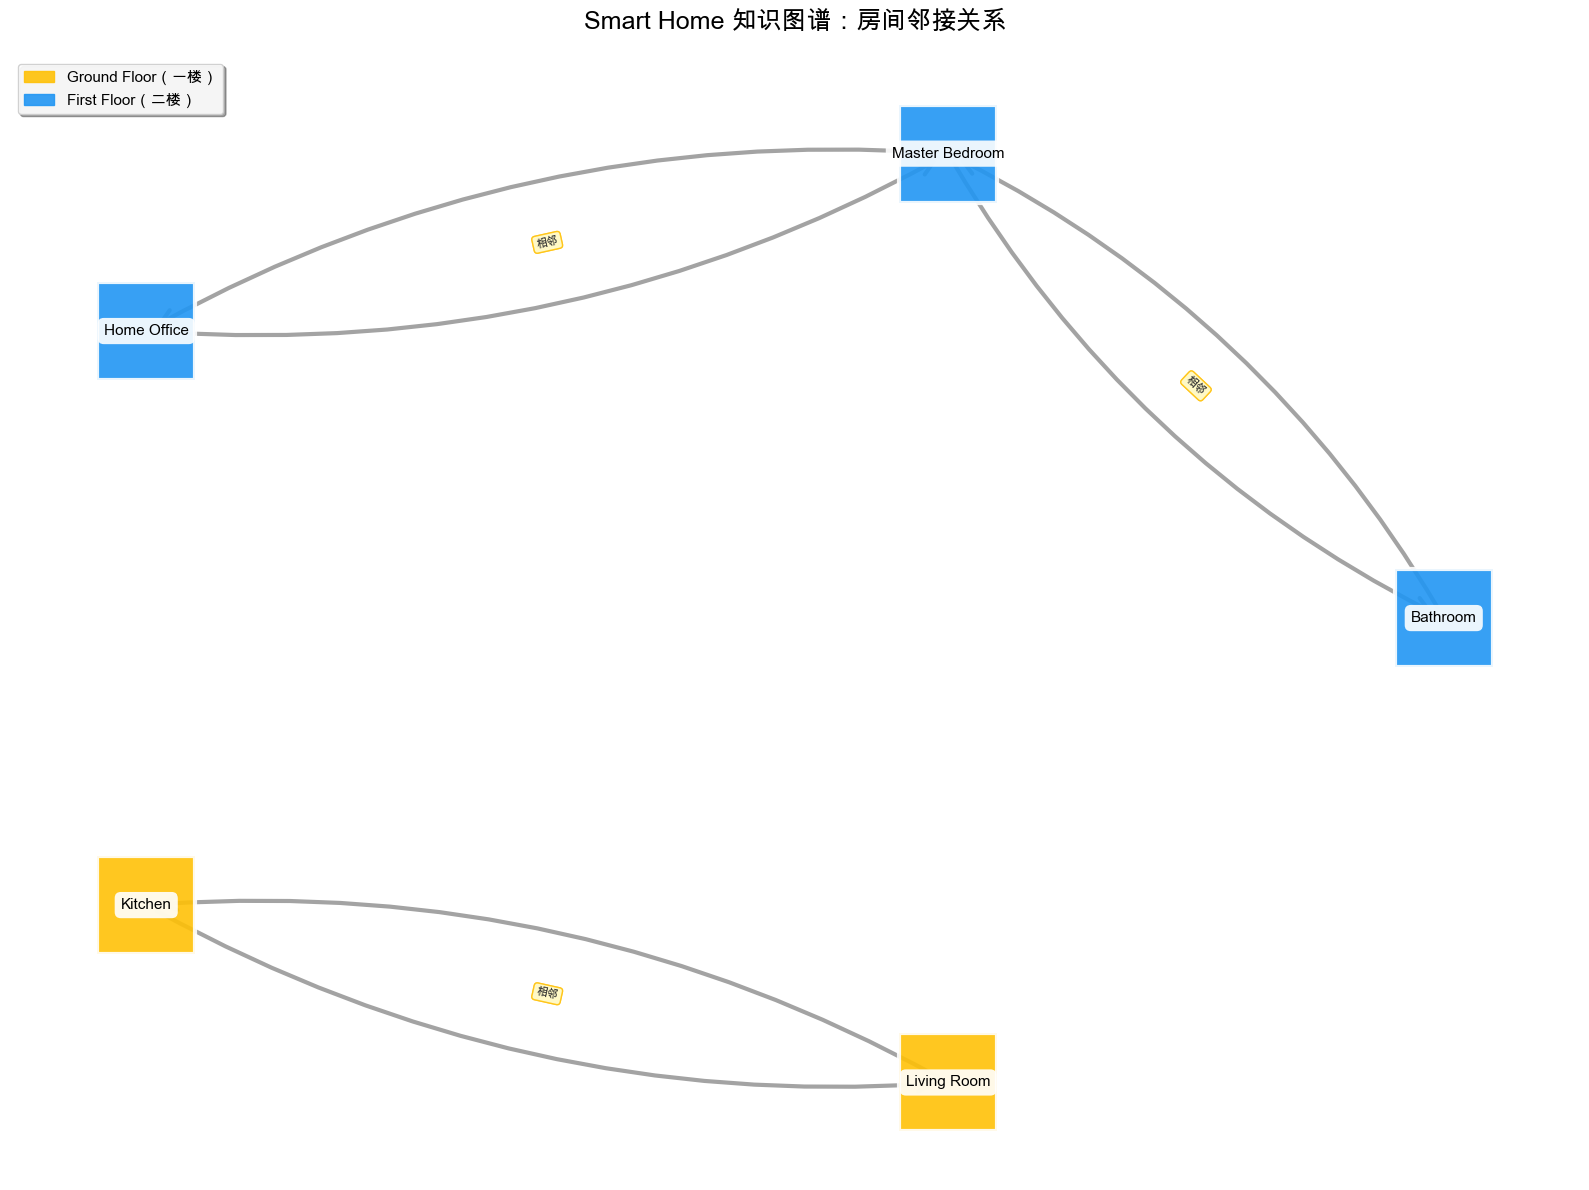


图统计:
  房间数: 5
  邻接关系数: 6
  关系类型: ADJACENT_TO (相邻)


In [97]:
if VISUALIZATION_AVAILABLE:
    # 查询房间邻接关系（包含关系类型）
    room_adj_data = conn.query("""
        MATCH (r1:Room)-[rel:ADJACENT_TO]->(r2:Room)
        RETURN r1.name AS room1, r1.floor AS floor1,
               r2.name AS room2, r2.floor AS floor2,
               type(rel) AS relationship_type
        ORDER BY room1, room2
    """)
    
    # 创建有向图
    G3 = nx.DiGraph()
    
    for row in room_adj_data:
        room1 = row['room1']
        room2 = row['room2']
        floor1 = row['floor1']
        floor2 = row['floor2']
        rel_type = row['relationship_type']
        
        G3.add_node(room1, floor=floor1)
        G3.add_node(room2, floor=floor2)
        G3.add_edge(room1, room2, relationship=rel_type)
    
    # 创建图形
    plt.figure(figsize=(16, 12))
    
    # 使用 circular layout（圆形布局）
    pos = nx.circular_layout(G3)
    
    # 按楼层着色
    floor_colors = {
        'Ground Floor': '#FFC107',
        'First Floor': '#2196F3'
    }
    
    # 绘制边（带箭头，显示关系）
    edges = G3.edges()
    nx.draw_networkx_edges(G3, pos, edges, alpha=0.6, edge_color='#666666', 
                          width=3, arrows=True, arrowsize=25,
                          arrowstyle='->', connectionstyle='arc3,rad=0.15')
    
    # 绘制节点（按楼层，带边框）
    for floor, color in floor_colors.items():
        floor_nodes = [n for n in G3.nodes() 
                      if G3.nodes[n].get('floor') == floor]
        if floor_nodes:
            nx.draw_networkx_nodes(G3, pos, nodelist=floor_nodes,
                                  node_color=color, node_size=5000,
                                  alpha=0.9, node_shape='s',
                                  edgecolors='white', linewidths=3)
    
    # 添加节点标签
    node_labels = {n: n for n in G3.nodes()}
    nx.draw_networkx_labels(G3, pos, node_labels, 
                           font_size=11, font_weight='bold',
                           bbox=dict(boxstyle='round,pad=0.4', 
                                   facecolor='white', 
                                   edgecolor='none', 
                                   alpha=0.9))
    
    # 添加关系标签（显示"相邻"）
    edge_labels = {}
    for (u, v) in G3.edges():
        rel_type = G3[u][v].get('relationship', '')
        if rel_type == 'ADJACENT_TO':
            edge_labels[(u, v)] = '相邻'
        else:
            edge_labels[(u, v)] = rel_type
    
    nx.draw_networkx_edge_labels(G3, pos, edge_labels, 
                                 font_size=8, font_color='#333333',
                                 bbox=dict(boxstyle='round,pad=0.3',
                                         facecolor='#FFF9C4',
                                         edgecolor='#FFC107',
                                         alpha=0.8))
    
    plt.title("Smart Home 知识图谱：房间邻接关系", 
             fontsize=18, fontweight='bold', pad=20)
    plt.axis('off')
    plt.tight_layout()
    
    # 添加图例
    legend_elements = [
        mpatches.Patch(color='#FFC107', label='Ground Floor（一楼）', alpha=0.9),
        mpatches.Patch(color='#2196F3', label='First Floor（二楼）', alpha=0.9),
    ]
    plt.legend(handles=legend_elements, loc='upper left', fontsize=11,
              framealpha=0.9, fancybox=True, shadow=True)
    
    plt.show()
    
    print(f"\n图统计:")
    print(f"  房间数: {G3.number_of_nodes()}")
    print(f"  邻接关系数: {G3.number_of_edges()}")
    print(f"  关系类型: ADJACENT_TO (相邻)")


### 12.5 可视化 4：统计图表（Plotly 交互式）

使用 Plotly 创建交互式统计图表。


In [98]:
if PLOTLY_AVAILABLE:
    # 查询每个房间的设备数量
    room_stats = conn.query("""
        MATCH (r:Room)-[:CONTAINS]->(d:Device)
        RETURN r.name AS room, count(d) AS device_count
        ORDER BY device_count DESC
    """)
    
    # 准备数据
    rooms = [row['room'] for row in room_stats]
    counts = [row['device_count'] for row in room_stats]
    
    # 创建柱状图
    fig = go.Figure(data=[
        go.Bar(
            x=rooms,
            y=counts,
            marker_color='#4CAF50',
            text=counts,
            textposition='outside',
            hovertemplate='<b>%{x}</b><br>设备数: %{y}<extra></extra>'
        )
    ])
    
    fig.update_layout(
        title='每个房间的设备数量',
        xaxis_title='房间',
        yaxis_title='设备数量',
        template='plotly_white',
        height=400
    )
    
    fig.show()
else:
    print("⚠️ 需要安装 plotly 才能显示交互式图表: pip install plotly")


In [99]:
if PLOTLY_AVAILABLE:
    # 查询每种设备类型的数量
    device_type_stats = conn.query("""
        MATCH (d:Device)
        RETURN d.device_type AS device_type, count(d) AS count
        ORDER BY count DESC
    """)
    
    device_types = [row['device_type'] for row in device_type_stats]
    counts = [row['count'] for row in device_type_stats]
    
    # 创建饼图
    fig = go.Figure(data=[
        go.Pie(
            labels=device_types,
            values=counts,
            hole=0.3,
            textinfo='label+percent',
            hovertemplate='<b>%{label}</b><br>数量: %{value}<br>占比: %{percent}<extra></extra>'
        )
    ])
    
    fig.update_layout(
        title='设备类型分布',
        template='plotly_white',
        height=500
    )
    
    fig.show()
else:
    print("⚠️ 需要安装 plotly 才能显示交互式图表")


### 12.6 可视化 5：完整知识图谱（所有节点和关系）

展示完整的知识图谱结构，包括所有节点类型和关系。


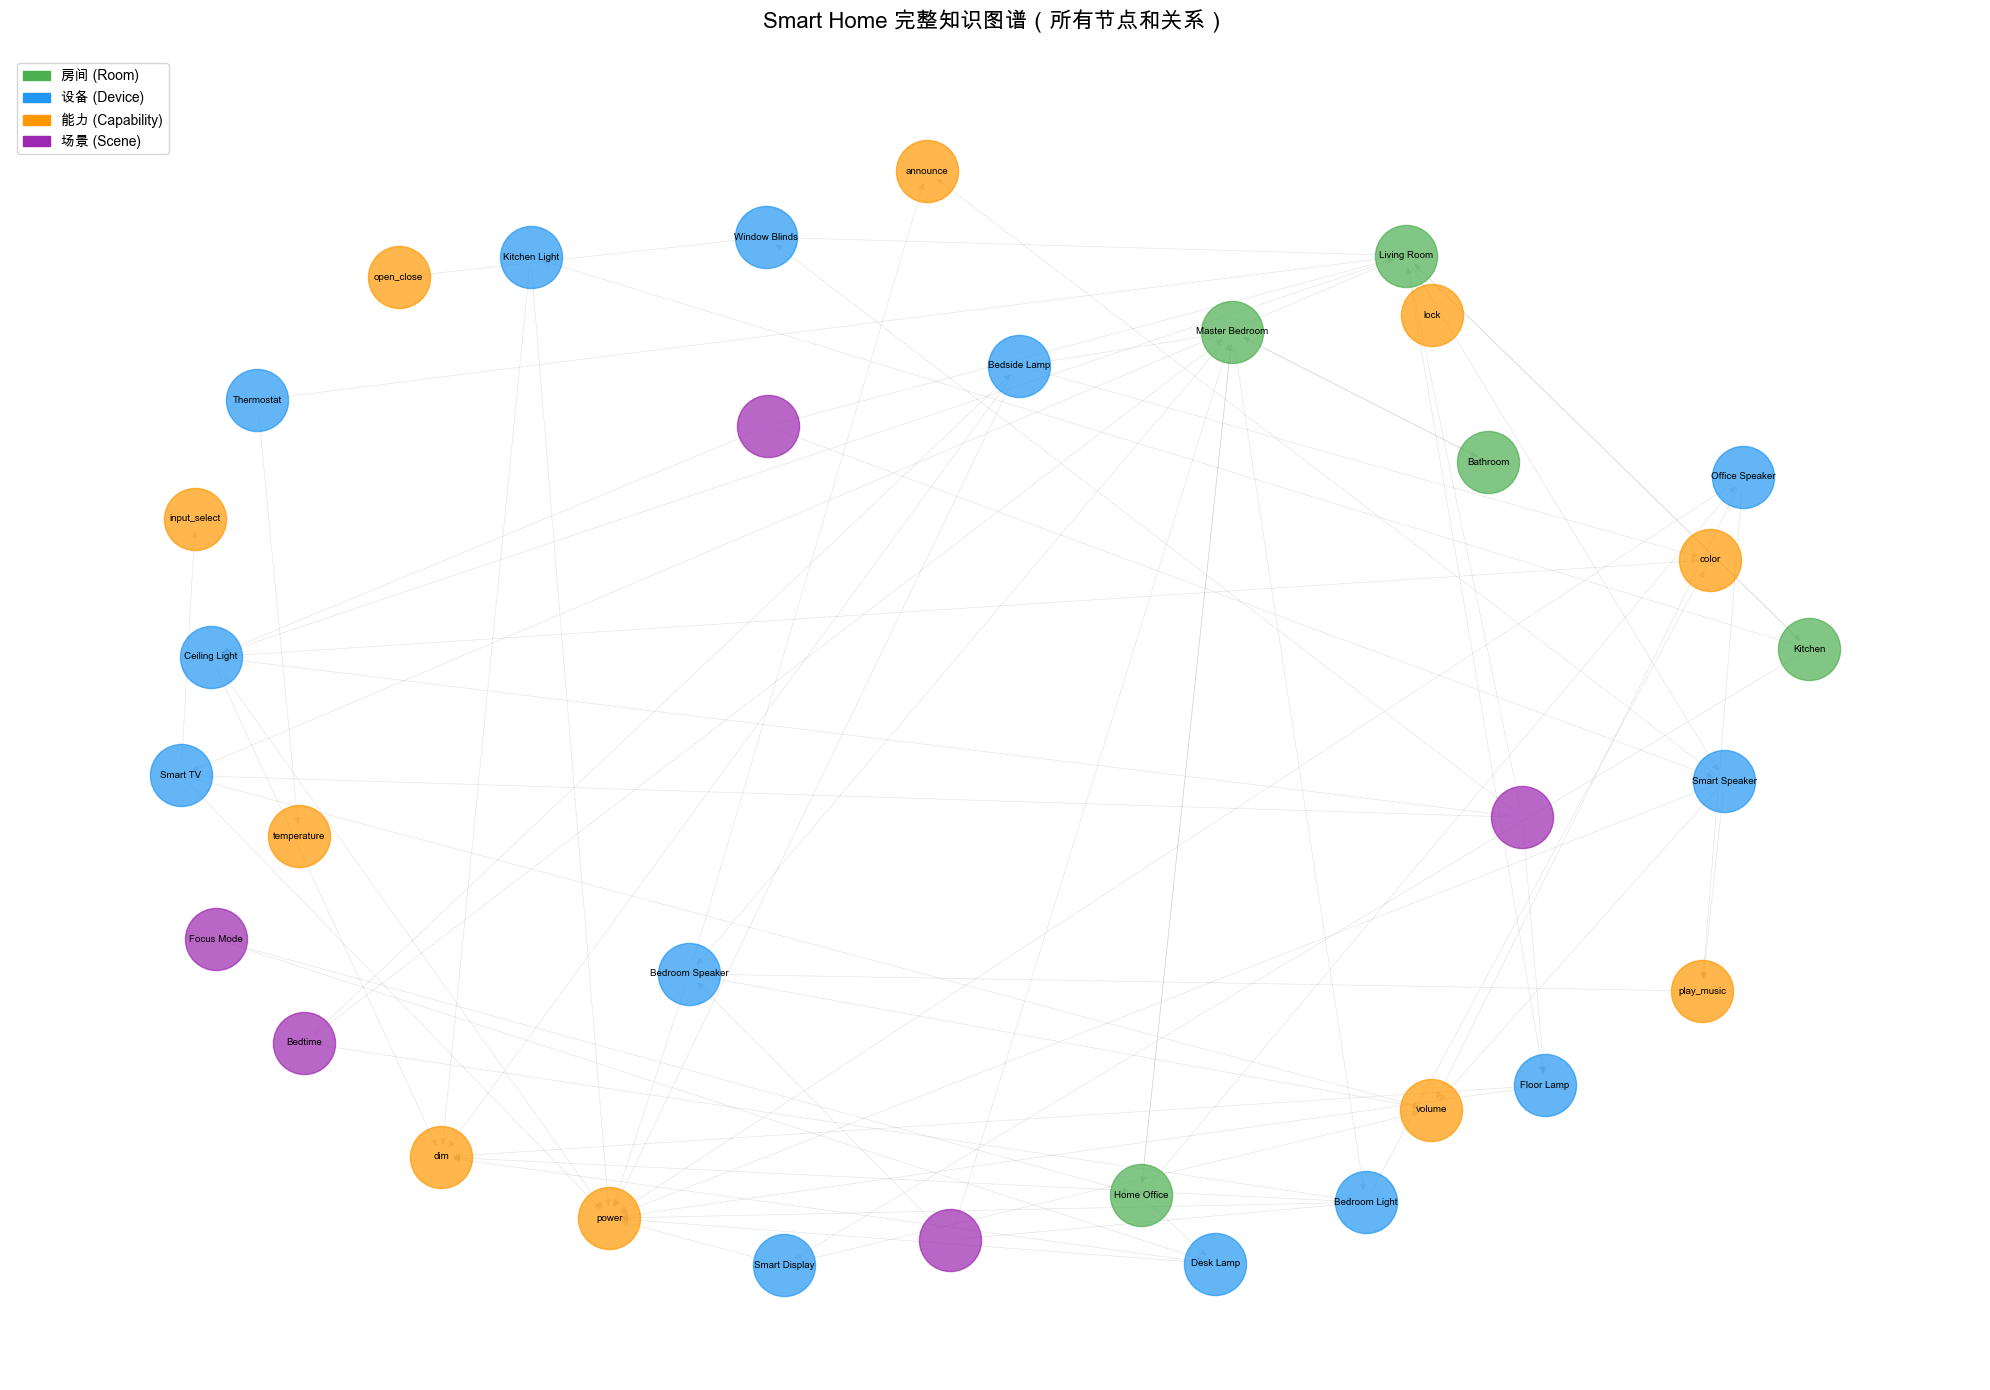


完整图统计:
  总节点数: 33
  总边数: 68
  节点类型: {'Room', 'Scene', 'Capability', 'Device'}


In [100]:
if VISUALIZATION_AVAILABLE:
    # 查询所有节点和关系
    all_nodes = conn.query("""
        MATCH (n)
        RETURN labels(n)[0] AS label, n.name AS name, 
               CASE 
                   WHEN n:Room THEN n.type
                   WHEN n:Device THEN n.device_type
                   ELSE null
               END AS subtype
        ORDER BY label, name
    """)
    
    all_rels = conn.query("""
        MATCH (a)-[r]->(b)
        RETURN labels(a)[0] AS from_label, a.name AS from_name,
               type(r) AS rel_type,
               labels(b)[0] AS to_label, b.name AS to_name
        LIMIT 100
    """)
    
    # 创建图
    G_full = nx.DiGraph()
    
    # 添加节点
    node_colors = {
        'Room': '#4CAF50',
        'Device': '#2196F3',
        'Capability': '#FF9800',
        'Scene': '#9C27B0'
    }
    
    for row in all_nodes:
        name = row['name']
        label = row['label']
        G_full.add_node(name, label=label, subtype=row['subtype'])
    
    # 添加边
    for row in all_rels:
        from_name = row['from_name']
        to_name = row['to_name']
        rel_type = row['rel_type']
        G_full.add_edge(from_name, to_name, rel_type=rel_type)
    
    # 创建图形
    plt.figure(figsize=(20, 14))
    
    # 使用 spring layout
    pos = nx.spring_layout(G_full, k=2, iterations=50, seed=42)
    
    # 绘制边
    nx.draw_networkx_edges(G_full, pos, alpha=0.2, edge_color='gray', 
                          width=0.5, arrows=True, arrowsize=10)
    
    # 按标签绘制节点
    for label, color in node_colors.items():
        label_nodes = [n for n in G_full.nodes() 
                      if G_full.nodes[n].get('label') == label]
        if label_nodes:
            nx.draw_networkx_nodes(G_full, pos, nodelist=label_nodes,
                                  node_color=color, node_size=2000,
                                  alpha=0.7, node_shape='o')
    
    # 只显示部分标签（避免太拥挤）
    important_nodes = []
    for row in all_nodes[:30]:  # 只显示前30个节点
        if row['name']:
            important_nodes.append(row['name'])
    
    labels_dict = {n: n for n in important_nodes if n in G_full.nodes()}
    nx.draw_networkx_labels(G_full, pos, labels_dict, 
                           font_size=7, font_weight='bold')
    
    plt.title("Smart Home 完整知识图谱（所有节点和关系）", 
             fontsize=16, fontweight='bold', pad=20)
    plt.axis('off')
    plt.tight_layout()
    
    # 添加图例
    legend_elements = [
        mpatches.Patch(color='#4CAF50', label='房间 (Room)'),
        mpatches.Patch(color='#2196F3', label='设备 (Device)'),
        mpatches.Patch(color='#FF9800', label='能力 (Capability)'),
        mpatches.Patch(color='#9C27B0', label='场景 (Scene)'),
    ]
    plt.legend(handles=legend_elements, loc='upper left', fontsize=10)
    
    plt.show()
    
    print(f"\n完整图统计:")
    print(f"  总节点数: {G_full.number_of_nodes()}")
    print(f"  总边数: {G_full.number_of_edges()}")
    print(f"  节点类型: {set([G_full.nodes[n].get('label') for n in G_full.nodes()])}")


## 13. 总结：Cypher 语法速查

In [101]:
# 清理连接
conn.close()
print("✓ 连接已关闭")


✓ 连接已关闭


In [102]:
# 清理连接
conn.close()
print("✓ 连接已关闭")


✓ 连接已关闭
